# Stage 3 – EDA, Step 9: Relationships with Price (Training Set)

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `07_eda_univariate.ipynb` (Step 8)

---

## Where we are

Step 8 described each feature on its own. Step 9 asks the central question of the project: **which features drive rent, and how?** It's still done on the **training set only**, so the test set stays a fair final exam.

The results decide three things:

1. **Which features matter most**, and so which ones the prediction platform must ask the user for.
2. **Whether the relationships are straight lines or curves.** Curved and "it depends" relationships favour tree models (Random Forest, LightGBM) over Linear Regression.
3. **Two open questions from Step 8:** whether rare categories are similar enough in rent to be grouped as "other", and whether small regions really need smoothing.

---

## Three ideas used throughout this notebook

**1. We study `log(price)`, not price.** Step 2 decided the models will predict `log1p(price)`, so that's the scale on which relationships matter. It also makes effects *proportional*: a feature that raises rent by 10% shows up as the same step for a \$700 apartment and a \$3,000 house. On the dollar scale, that would be \$70 in one case and \$300 in the other. All charts are labelled in dollars so they stay easy to read.

**2. Differences are reported as percentages of the median.** "Listings with a garage have a 25% higher median rent" is easier to understand than a difference in log units, and it's comparable across features. (The median is used rather than the mean because rents are skewed, as in every earlier step.)

**3. One measure makes every feature comparable: "variance explained" (η², eta-squared).** Rents vary a lot between listings. For any feature, we can ask: *if we knew only this feature, how much of that variation would we account for?*

   - Group the listings by the feature's values (for example, by property type).
   - Replace each listing's log rent by its group's average.
   - η² is the share of the total variation that these group averages reproduce.

   **η² = 0** means the feature tells us nothing about rent; **η² = 1** would mean it tells us everything. It works the same way for categories, counts and measurements (measurements are first cut into 20 equal-sized bins), so 9.8 can rank **all** features on one scale.

   One caution: a feature with very many groups (like 413 regions) gets a small, automatic boost, because some groups fit their few listings by chance. With 150,000 listings and a few hundred groups that boost is tiny (well under 1 percentage point), but the notebook mentions it where it matters.

**What this step does *not* do:** it looks at one feature at a time against rent. How features overlap with each other (size and bedrooms, for example, clearly move together) is **Step 10**.

## 9.0 Setup

**What this cell does:** the usual imports and helpers, then it loads the **training set** with `load_train()` and adds `log_price = log(1 + price)`.

It defines three small helpers used by every section:

- **`dollar_axis(ax)`** labels a log-price axis in dollars (\$250, \$500, \$1,000, …) so charts stay readable.
- **`eta_squared(groups)`** computes the "variance explained" measure described above.
- **`group_table(col)`** gives, for each value of a feature, its number of listings, median rent, and the % difference from the overall median rent.

Blank laundry and parking values are shown as the category `missing`, exactly as the pipeline will treat them (Step 3).

In [11]:
# 9.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

train = load_train()          # the TRAINING set only; the test set stays locked
train["log_price"] = np.log1p(train["price"])
for col in ["laundry_options", "parking_options"]:
    train[col] = train[col].fillna("missing")      # as the pipeline will treat blanks (Step 3)

overall_median = train["price"].median()
print(f"Training listings: {len(train):,}   |   overall median rent: ${overall_median:,.0f}")

PRICE_TICKS = [250, 500, 1000, 2000, 4000, 10000]

def dollar_axis(ax, axis="y", ticks=PRICE_TICKS):
    # Label a log1p(price) axis in dollars
    pos = np.log1p(ticks)
    labels = [f"${t:,}" for t in ticks]
    if axis == "y":
        ax.set_yticks(pos); ax.set_yticklabels(labels)
    else:
        ax.set_xticks(pos); ax.set_xticklabels(labels)

def eta_squared(groups, y=None):
    # Share of the variation in log price reproduced by the group averages (0 = nothing, 1 = everything)
    y = train["log_price"] if y is None else y
    group_mean = y.groupby(groups.astype(str)).transform("mean")
    return 1 - ((y - group_mean) ** 2).sum() / ((y - y.mean()) ** 2).sum()

def group_table(col, data=None):
    # Listings, median rent and % difference from the overall median, for each value of col
    data = train if data is None else data
    t = data.groupby(col)["price"].agg(listings="size", median_rent="median")
    t["vs_overall_%"] = (t["median_rent"] / overall_median - 1) * 100
    return t.sort_values("median_rent")

show_obs(8)   # Step 8 findings, to confirm the handover

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training listings: 150,404   |   overall median rent: $1,150


,step,observation,evidence,decision
0,8-Univariate,"150,404 training listings, 16 features; near-c...",8.1 feature overview,High-cardinality categories need special encod...
1,8-Univariate,sqfeet skew 2.53 raw vs 0.14 after log1p (trai...,8.2 summary table and histograms,Log-transform and standardise sqfeet for Linea...
2,8-Univariate,21.4% of sizes are multiples of 100 sq ft (abo...,8.2 (cont.) rounded sizes,No action; report as a data limitation that ca...
3,8-Univariate,"beds skew 0.56, baths skew 0.99; 11.5% have a ...",8.3 bar charts,Keep beds and baths as numeric (ordered counts...
4,8-Univariate,969 training listings (0.64%) have no coordina...,8.4 histograms and coverage map,Fill missing pins from the region centre (trai...
5,8-Univariate,"413 regions: median 200 listings, 29 with < 30...","8.5 listings per category, top-15 state chart",Target-encode region_url with smoothing and cr...
6,8-Univariate,"type: 4 categories under 1% (cottage/cabin, fl...",8.6 category bar charts,One-hot encode with min_frequency = 1% of trai...
7,8-Univariate,laundry_options: 0 categories under 1%,8.6 category bar charts,One-hot encode; no grouping needed
8,8-Univariate,parking_options: 2 categories under 1% (no par...,8.6 category bar charts,One-hot encode with min_frequency = 1% of trai...
9,8-Univariate,Binary flags yes-share: electric_vehicle_charg...,8.7 binary flag chart,Use as 0/1 (standardised for sensitive models)...


## 9.1 Rent and size

**What this cell does:** it draws a **hexbin plot** of log size (across) against log rent (up), then overlays the **median rent** in 25 size bands (the red line). It also computes two correlation measures and a slope.

**Why a hexbin instead of a scatter plot?** With 150,000 listings, an ordinary scatter plot becomes a solid blob where you can't see where most points are. A hexbin divides the chart into small hexagons and colours each by **how many listings fall inside it**. Dark areas are where the data really is.

**The two correlation measures:**

- **Pearson's r** measures how well a **straight line** fits.
- **Spearman's ρ (rho)** measures whether rent **tends to rise** with size, whether or not the rise is a straight line. It works on ranks, so it's also robust to skew.

If Spearman is clearly higher than Pearson, the relationship is consistent but **curved**. Both range from −1 to +1; around 0.5 is a moderate relationship for messy real-world data.

**The slope, read as an elasticity:** because both axes are on a log scale, the slope of the straight-line fit has a simple meaning: *"a 1% larger home rents for about b% more."* A slope below 1 means rent rises more slowly than size: doubling the size doesn't double the rent. That's what we'd expect, since part of any rent is a fixed "cost of having a home in this place".

**An important caution:** this is the relationship *across the whole country*. Large homes are more common in cheap rural areas, and small apartments in expensive cities. That mixing (called **confounding** by location) can hide or weaken the real effect of size. Step 10 looks at size *within* locations.

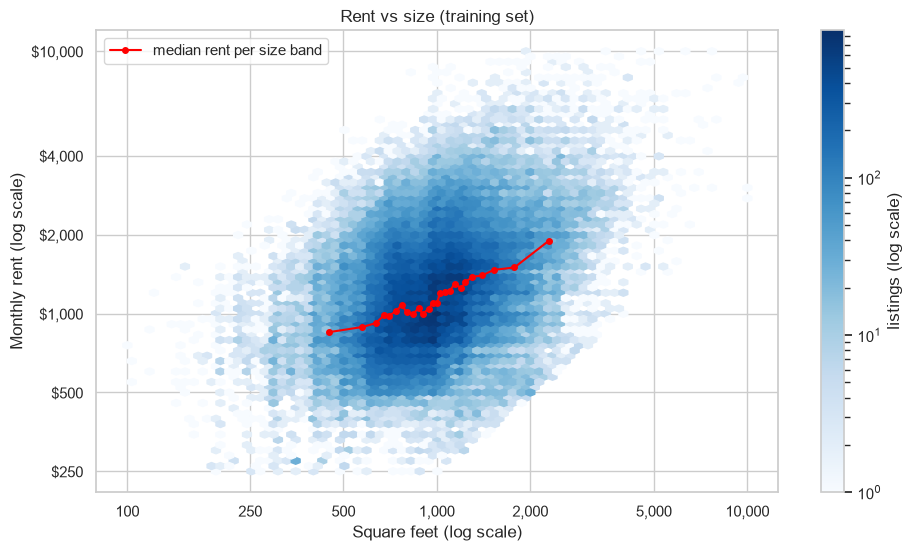

Pearson r (log-log):  0.381
Spearman rho:         0.360
Elasticity (slope):   0.45  ->  a 10% larger home rents for about 4.5% more


In [12]:
# 9.1 Size vs rent: hexbin, binned medians, correlations and elasticity

log_sq = np.log1p(train["sqfeet"])
fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(log_sq, train["log_price"], gridsize=70, bins="log", cmap="Blues", mincnt=1)
fig.colorbar(hb, ax=ax, label="listings (log scale)")

size_bands = pd.qcut(log_sq, 25, duplicates="drop")
band_median = train.groupby(size_bands, observed=True).agg(x=("sqfeet", lambda s: np.log1p(s).median()),
                                                           y=("log_price", "median"))
ax.plot(band_median["x"], band_median["y"], color="red", marker="o", markersize=4, label="median rent per size band")

size_ticks = [100, 250, 500, 1000, 2000, 5000, 10000]
ax.set_xticks(np.log1p(size_ticks)); ax.set_xticklabels([f"{t:,}" for t in size_ticks])
dollar_axis(ax)
ax.set(xlabel="Square feet (log scale)", ylabel="Monthly rent (log scale)", title="Rent vs size (training set)")
ax.legend(loc="upper left")
save_fig("09_rent_vs_size")
plt.show()

r_pearson = pearsonr(log_sq, train["log_price"])[0]
r_spearman = spearmanr(train["sqfeet"], train["price"])[0]
elasticity = np.polyfit(log_sq, train["log_price"], 1)[0]
print(f"Pearson r (log-log):  {r_pearson:.3f}")
print(f"Spearman rho:         {r_spearman:.3f}")
print(f"Elasticity (slope):   {elasticity:.2f}  ->  a 10% larger home rents for about {elasticity * 10:.1f}% more")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.1 Findings

- **Rent rises with size, but only moderately:** Pearson (log-log) **0.381**, Spearman **0.360**.
- **Elasticity 0.45:** a **10% larger home rents for about 4.5% more.**
- **Size alone explains about 14.5%** of the variation in log rent (0.381² ≈ 0.145). The binned η² in 9.8 gives almost the same number (**14.4%**), which means the relationship on the log–log scale is close to a **straight line**: grouping sizes into bands doesn't find any extra curved pattern. The log's verdict is therefore "roughly linear on log scales" (Spearman is not above Pearson).
- **What the chart shows:** the red median line rises steadily; it's a little flatter below about 700 sq ft and has a small wobble around 900–1,000 sq ft (the rounded sizes from Step 8). The **vertical spread is huge**: a 1,000 sq ft home can rent for anything from about $500 to $4,000. Size alone can't explain that spread; **location** is the obvious candidate (9.6–9.8).
- **4.5% per 10% looks low.** A likely reason is **confounding**: expensive cities have smaller homes, which hides part of the size effect. **Step 10.4 measures this** by comparing homes within the same region.

## 9.2 Rent by bedrooms and bathrooms

**What this cell does:** it draws **box plots of rent for each number of bedrooms and bathrooms** (on the log scale, labelled in dollars), and prints the median rent and listing count for each value.

**How to read a box plot** (as in Step 6): the box covers the middle half of the listings, the line inside is the median, and the whiskers reach the typical range. Outlier dots are hidden here (`showfliers=False`) because with 150,000 listings they'd clutter the chart without adding anything.

**What to look for:**

- **Does the median rise steadily** with each extra bedroom or bathroom? A steady rise supports keeping them as **numbers** (Step 8's decision): one "per bedroom" effect fits.
- **Do the boxes overlap a lot?** Heavy overlap means the count alone can't separate cheap from expensive listings. A 2-bed in San Francisco costs more than a 4-bed in Ohio, which is location again.
- **Studios (0 beds)** are worth a look. They're small, but often in city centres, so their rent may not be the lowest.

Values with very few listings (7–8 beds, 6+ baths) are merged into a top group for the chart, so their boxes aren't built from a handful of homes.

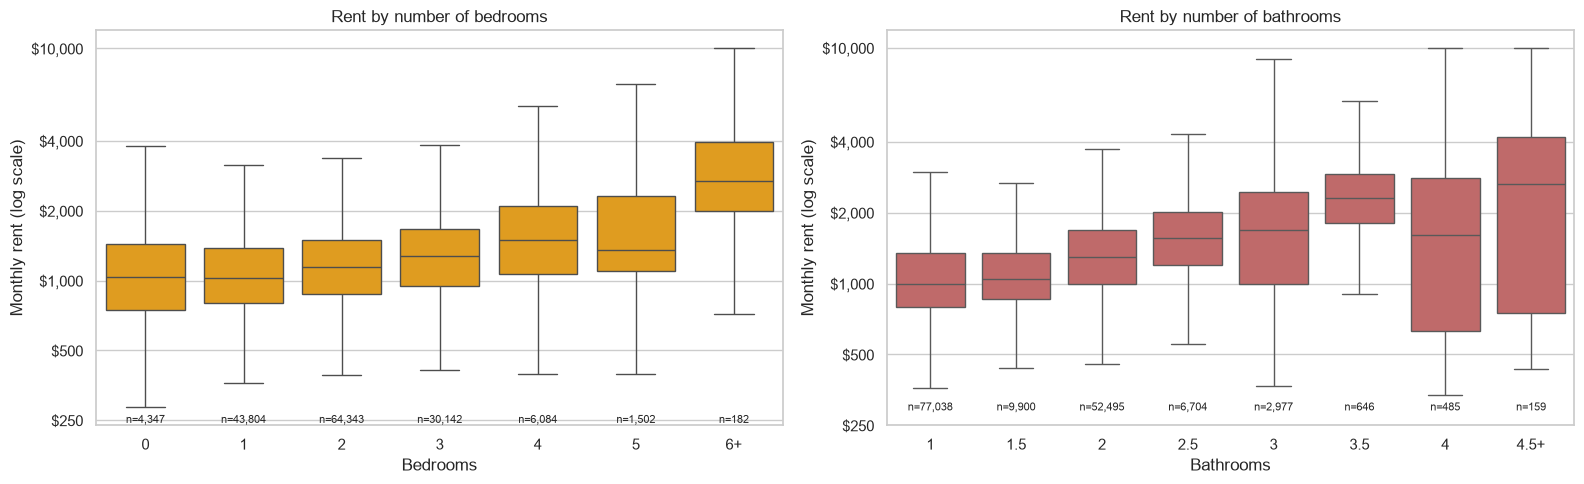


beds:


beds,0,1,2,3,4,5,6+
listings,"4,347","43,804","64,343","30,142","6,084","1,502",182
median_rent,"1,035","1,029","1,145","1,282","1,500","1,349","2,680"
change_vs_previous_%,nan,-1,11,12,17,-10,99



baths:


baths,1,1.5,2,2.5,3,3.5,4,4.5+
listings,"77,038","9,900","52,495","6,704","2,977",646,485,159
median_rent,"1,000","1,050","1,300","1,565","1,690","2,300","1,600","2,650"
change_vs_previous_%,nan,5,24,20,8,36,-30,66


In [13]:
# 9.2 Rent by bedrooms and bathrooms

beds_grp = train["beds"].clip(upper=6).map(lambda v: "6+" if v >= 6 else str(int(v)))
baths_grp = train["baths"].clip(upper=4.5).map(lambda v: "4.5+" if v >= 4.5 else f"{v:g}")
beds_order = [v for v in [str(i) for i in range(6)] + ["6+"] if v in set(beds_grp)]   # only values present
baths_order = sorted(baths_grp.unique(), key=lambda s: float(s.rstrip("+")))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, grp, order, name, color in [(axes[0], beds_grp, beds_order, "Bedrooms", "orange"),
                                    (axes[1], baths_grp, baths_order, "Bathrooms", "indianred")]:
    sns.boxplot(x=grp, y=train["log_price"], order=order, ax=ax, color=color, showfliers=False)
    counts = grp.value_counts()
    for i, v in enumerate(order):
        ax.text(i, ax.get_ylim()[0], f"n={counts.get(v, 0):,}", ha="center", va="bottom", fontsize=8)
    dollar_axis(ax)
    ax.set(xlabel=name, ylabel="Monthly rent (log scale)", title=f"Rent by number of {name.lower()}")
plt.tight_layout()
save_fig("09_rent_by_beds_baths")
plt.show()

for name, grp in [("beds", beds_grp), ("baths", baths_grp)]:
    t = train.groupby(grp)["price"].agg(listings="size", median_rent="median")
    t = t.loc[beds_order if name == "beds" else baths_order]
    t["change_vs_previous_%"] = t["median_rent"].pct_change() * 100
    print(f"\n{name}:")
    display(t.T.style.format("{:,.0f}"))

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.2 Findings

**Bedrooms** (median rent; change vs previous):

| Beds | 0 | 1 | 2 | 3 | 4 | 5 | 6+ |
|---|---|---|---|---|---|---|---|
| Median | $1,035 | $1,029 | $1,145 | $1,282 | $1,500 | $1,349 | $2,680 |
| Change | – | −1% | +11% | +12% | +17% | **−10%** | +99% |
| Listings | 4,347 | 43,804 | 64,343 | 30,142 | 6,084 | 1,502 | 182 |

**Bathrooms:** 1: $1,000 · 1.5: $1,050 · 2: $1,300 (+24%) · 2.5: $1,565 · 3: $1,690 · 3.5: $2,300 · **4: $1,600 (−30%)** · 4.5+: $2,650.

- **The general trend is up**, but the **boxes overlap heavily**: a 1-bed and a 3-bed can easily rent for the same amount in different places.
- **Studios rent for the same as 1-bedroom homes** ($1,035 vs $1,029). Studios are mostly a big-city product, so this is probably **location**, not a real studio premium → checked in **Step 10.4**.
- **Two anomalies:** 5 bedrooms is **cheaper** than 4 (−10%), and the **4-bathroom box is very wide**, reaching down to about $600. A likely cause is **student housing leased per bedroom** (a 4-bed/4-bath apartment advertised at the price of one room) → checked in **Step 10.7**.
- **Bathrooms relate to rent more steadily than bedrooms** (η² **10.8%** vs **4.6%** in 9.8). Bathrooms seem to capture home quality and newness as well as size.
- **6+ bedrooms (182 listings)** jump to $2,680, but they rest on few examples.

## 9.3 Rent by property type, laundry and parking

**What this cell does:** for `type`, `laundry_options` and `parking_options`, it draws box plots of rent for every category, **sorted from cheapest to most expensive median**, with the number of listings under each box. Blanks appear as `missing`, and the categories below the Step 8 rare threshold are coloured red.

**What to look for:**

- **The spread between the cheapest and most expensive category.** A wide spread means the feature carries real information about rent.
- **Where `missing` sits.** Step 3 found that blanks sit mid-range on the full data. If that holds on the training set, the `"missing"` category is doing its job: blanks behave like ordinary listings, not like a hidden "no amenity".
- **Where the rare (red) categories sit.** This matters for the next section. If they sit close together, grouping them loses little. If they're at opposite ends, grouping them would be a mistake.

**Why this is not "cause and effect":** an attached garage may go with higher rents partly because garages are more common in newer suburban houses, not only because renters pay for the garage itself. Step 9 describes *associations*. The models will use them for **prediction**, which is fine, but the report shouldn't claim that adding a garage *causes* a rent increase.

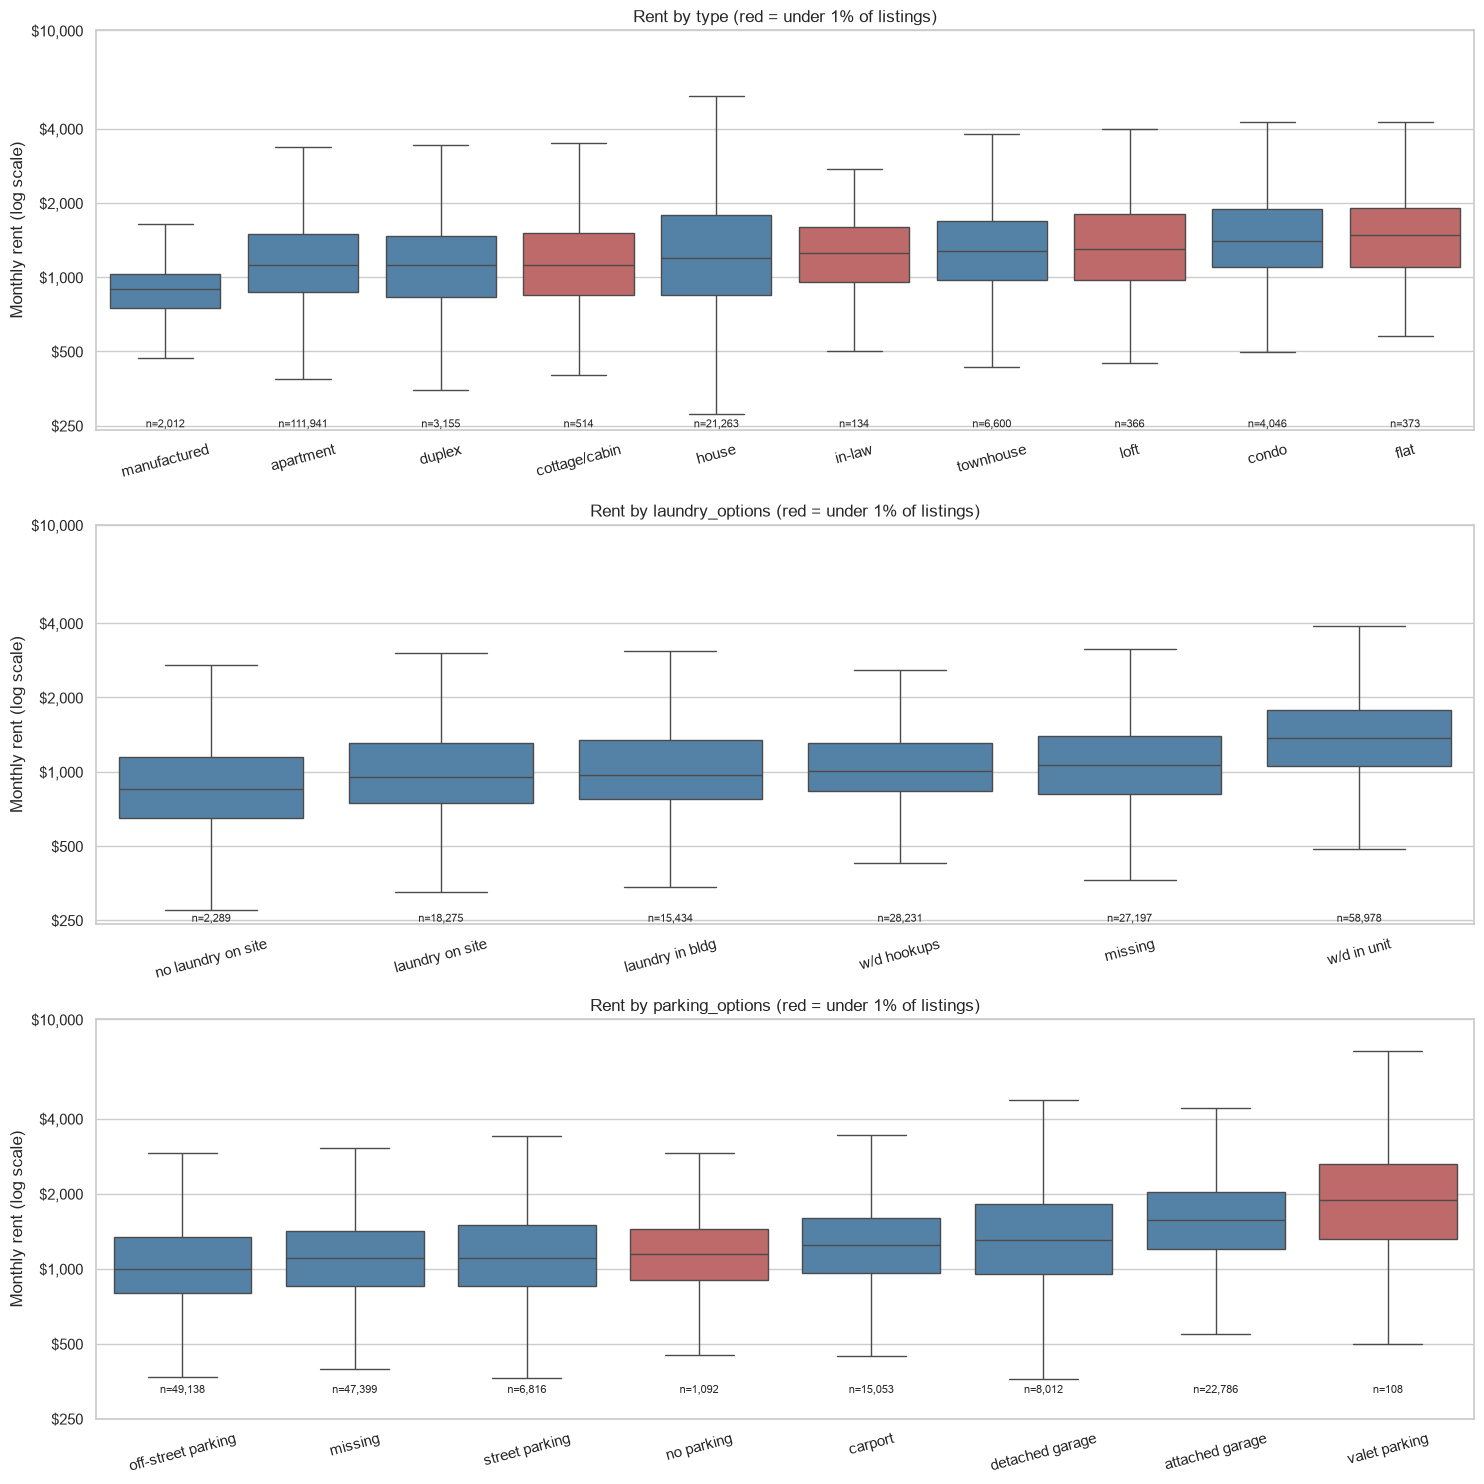


type:


,listings,median_rent,vs_overall_%
type,,,
manufactured,"2,012",$899,-21.8%
apartment,"111,941","$1,122",-2.4%
duplex,"3,155","$1,125",-2.2%
cottage/cabin,514,"$1,125",-2.2%
house,"21,263","$1,201",+4.4%
in-law,134,"$1,250",+8.7%
townhouse,"6,600","$1,280",+11.3%
loft,366,"$1,306",+13.6%
condo,"4,046","$1,400",+21.7%



laundry_options:


,listings,median_rent,vs_overall_%
laundry_options,,,
no laundry on site,"2,289",$850,-26.1%
laundry on site,"18,275",$949,-17.5%
laundry in bldg,"15,434",$970,-15.7%
w/d hookups,"28,231","$1,004",-12.7%
missing,"27,197","$1,069",-7.0%
w/d in unit,"58,978","$1,372",+19.3%



parking_options:


,listings,median_rent,vs_overall_%
parking_options,,,
off-street parking,"49,138","$1,000",-13.0%
missing,"47,399","$1,099",-4.4%
street parking,"6,816","$1,100",-4.3%
no parking,"1,092","$1,150",+0.0%
carport,"15,053","$1,240",+7.8%
detached garage,"8,012","$1,300",+13.0%
attached garage,"22,786","$1,569",+36.4%
valet parking,108,"$1,894",+64.7%


In [14]:
# 9.3 Rent by category, sorted by median

cat_cols = ["type", "laundry_options", "parking_options"]
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
for ax, col in zip(axes, cat_cols):
    order = train.groupby(col)["log_price"].median().sort_values().index.tolist()
    share = train[col].value_counts(normalize=True)
    palette = {c: ("indianred" if share[c] < RARE_MIN_SHARE else "steelblue") for c in order}
    sns.boxplot(x=train[col], y=train["log_price"], order=order, ax=ax, hue=train[col],
                palette=palette, legend=False, showfliers=False)
    counts = train[col].value_counts()
    for i, c in enumerate(order):
        ax.text(i, ax.get_ylim()[0], f"n={counts[c]:,}", ha="center", va="bottom", fontsize=8)
    dollar_axis(ax)
    ax.set(xlabel="", ylabel="Monthly rent (log scale)", title=f"Rent by {col} (red = under {RARE_MIN_SHARE:.0%} of listings)")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
save_fig("09_rent_by_category")
plt.show()

for col in cat_cols:
    print(f"\n{col}:")
    display(group_table(col).style.format({"listings": "{:,}", "median_rent": "${:,.0f}", "vs_overall_%": "{:+.1f}%"}))

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.3 Findings

**`type`** (cheapest → dearest median): manufactured **$899 (−21.8%)**, apartment $1,122, duplex $1,125, cottage/cabin $1,125, house $1,201, in-law $1,250, townhouse $1,280, loft $1,306, condo $1,400, flat **$1,480 (+28.7%)**.
- Manufactured homes are clearly the cheapest. Houses have the **widest** box (from cheap rural houses to luxury homes).
- Despite a 65% spread between the cheapest and dearest medians, type explains only **2.0%** of the variation (9.8): **74% of listings are apartments**, so type separates only a small share of listings.

**`laundry_options`** – a clean amenity ladder: no laundry on site **$850 (−26.1%)** → laundry on site $949 → laundry in bldg $970 → w/d hookups $1,004 → **missing $1,069** → w/d in unit **$1,372 (+19.3%)**.
- **"Missing" sits in the middle**, not next to "no laundry on site". This confirms Step 3: blanks are not a hidden "none", so they correctly get their own `"missing"` category rather than being filled with the most common value.

**`parking_options`**: off-street **$1,000 (−13.0%)**, missing $1,099, street $1,100, no parking $1,150, carport $1,240, detached garage $1,300, attached garage **$1,569 (+36.4%)**, valet **$1,894 (+64.7%)**.
- Garages and valet parking go with higher rents, as expected.
- **"No parking" rents for *more* than "off-street parking".** That's a location effect: car-free listings are concentrated in dense, expensive cities, while off-street parking is typical of cheaper suburban and small-town complexes. **Step 10.4** repeats the comparison within regions.
- As with laundry, **"missing" sits mid-range**.

## 9.4 Can the rare categories be grouped?

This answers the open question from Step 8.

**The problem:** the pipeline plan is to merge categories below 1% of listings into one `"other"` category (`OneHotEncoder(min_frequency=...)`). That's only sensible if the merged categories have **similar rents**. Otherwise the model can't tell them apart any more. In `parking_options`, the two rare categories are **"no parking"** and **"valet parking"**, which sound like opposite ends of the amenity scale.

**What this cell does:** for each column, it takes the categories that would be merged and compares their median rents:

- **spread:** the difference between the most and least expensive of the merged categories, as a % of the cheaper one;
- **verdict:** "safe to group" if the spread is **under 20%**, otherwise "do not group blindly".

**Why 20%?** It's a practical line, not a statistical law. Differences of a few percent are within the noise of small groups. A difference of 50% or more is clearly two different kinds of listing. 20% sits comfortably between the two. The table shows the actual spread, so you can judge borderline cases yourself.

**If a column fails the check,** the fix is small and still leak-free. Lower the rare threshold for that column (so a category like "no parking", at about 0.7% or roughly 1,100 listings, keeps its own column), or map the rare category to a similar common one by hand. 9.9 records which option the evidence supports.

In [15]:
# 9.4 Are the categories that would be merged similar in rent?

GROUPING_SPREAD_LIMIT = 20   # % difference in median rent above which merging hides a real difference

rare_rows = []
for col in cat_cols:
    share = train[col].value_counts(normalize=True)
    rare_cats = share[share < RARE_MIN_SHARE].index.tolist()
    if len(rare_cats) == 0:
        rare_rows.append({"column": col, "rare categories": "none", "listings": 0,
                          "cheapest median": np.nan, "dearest median": np.nan, "spread_%": np.nan, "verdict": "nothing to group"})
        continue
    med = train[train[col].isin(rare_cats)].groupby(col)["price"].median()
    spread = (med.max() / med.min() - 1) * 100 if len(med) > 1 else 0.0
    rare_rows.append({
        "column": col,
        "rare categories": ", ".join(f"{c} (${m:,.0f})" for c, m in med.sort_values().items()),
        "listings": int(train[col].isin(rare_cats).sum()),
        "cheapest median": med.min(), "dearest median": med.max(), "spread_%": spread,
        "verdict": "safe to group" if spread < GROUPING_SPREAD_LIMIT else "do not group blindly",
    })
rare_check = pd.DataFrame(rare_rows).set_index("column")
with pd.option_context("display.max_colwidth", 120):
    display(rare_check.style.format({"listings": "{:,}", "cheapest median": "${:,.0f}", "dearest median": "${:,.0f}",
                                     "spread_%": "{:.0f}%"}, na_rep="-"))

,rare categories,listings,cheapest median,dearest median,spread_%,verdict
column,,,,,,
type,"cottage/cabin ($1,125), in-law ($1,250), loft ($1,306), flat ($1,480)","1,387","$1,125","$1,480",32%,do not group blindly
laundry_options,none,0,-,-,-,nothing to group
parking_options,"no parking ($1,150), valet parking ($1,894)","1,200","$1,150","$1,894",65%,do not group blindly


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.4 Findings – can the rare categories be grouped?

| Column | Rare categories (median rent) | Spread | Verdict |
|---|---|---|---|
| `type` | cottage/cabin $1,125, in-law $1,250, loft $1,306, flat $1,480 | **32%** | do not group blindly |
| `laundry_options` | none | – | nothing to group |
| `parking_options` | no parking $1,150, valet parking $1,894 | **65%** | do not group blindly |

- Both spreads are well above the **20%** limit, so merging these categories into one "other" column would throw away a real rent difference. The parking case is the extreme one: the cheapest and the most expensive parking options would become the same column.

**Decision:** replace the "under 1% → other" rule with a **minimum count**: every category with **at least 50 training listings keeps its own one-hot column**; only smaller ones (none at present) become "infrequent". Add this to `src/utils.py`:

```python
# Step 9
RARE_MIN_COUNT = 50   # 9.4: the rare categories differ in rent (type 32%, parking 65% spread), so every
                      #      category with 50+ training listings keeps its own one-hot column
```

and use it later as `OneHotEncoder(min_frequency=RARE_MIN_COUNT, handle_unknown="infrequent_if_exist")`.

**Why 50:** the smallest category, valet parking, has 108 listings; inside a 5-fold cross-validation training fold that's about 86, still above 50, so it keeps its column in every fold. Keeping every category costs almost nothing (about 24 one-hot columns in total), and Ridge's penalty stops a coefficient built on ~100 listings from becoming extreme. `RARE_MIN_SHARE` stays in `utils.py` as the EDA "flag for attention" threshold.

## 9.5 Binary flags: rent with and without each feature

**What this cell does:** for each of the six yes/no flags, it compares the median rent of listings **with** the feature (1) and **without** it (0). It reports the difference as a %, together with the number of listings on each side, and shows the differences as a bar chart.

**What to look for:**

- **Large differences** mean the flag carries information. Differences of only a few percent mean it adds little on its own.
- **The direction.** Some flags may point the "wrong" way at first sight. For example, listings that *allow smoking* might be **cheaper**, simply because smoking-friendly rentals are more common in cheaper markets and older buildings. That's an association, not a cost of smoking.
- **`smoking_allowed`** gets extra attention, because Steps 1 and 8 suspected Craigslist sets it to "allowed" by default. If it still shows a clear rent difference, it's useful to the model whatever it truly measures. If the difference is near 0, it's probably mostly noise.
- **Rare flags** (EV charging at about 2% yes) are based on fewer "yes" listings, so their difference is less certain.

,yes_listings,median_yes,median_no,difference_%
flag,,,,
smoking_allowed,"101,314","$1,095","$1,280",-14.5%
cats_allowed,"103,334","$1,141","$1,175",-2.9%
dogs_allowed,"100,024","$1,150","$1,150",+0.0%
comes_furnished,"8,350","$1,200","$1,150",+4.3%
wheelchair_access,"12,534","$1,299","$1,139",+14.0%
electric_vehicle_charge,"2,916","$1,685","$1,145",+47.2%


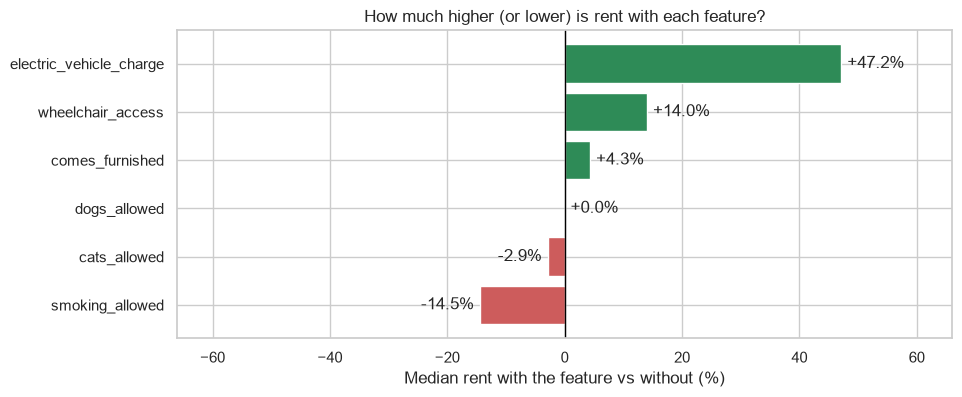

In [16]:
# 9.5 Median rent with vs without each flag

flag_rows = []
for col in BINARY_COLS:
    med = train.groupby(col)["price"].median()
    n = train[col].value_counts()
    flag_rows.append({"flag": col, "yes_listings": int(n.get(1, 0)), "median_yes": med.get(1, np.nan),
                      "median_no": med.get(0, np.nan), "difference_%": (med.get(1) / med.get(0) - 1) * 100})
flags = pd.DataFrame(flag_rows).set_index("flag").sort_values("difference_%")
display(flags.style.format({"yes_listings": "{:,}", "median_yes": "${:,.0f}", "median_no": "${:,.0f}",
                            "difference_%": "{:+.1f}%"}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(flags.index, flags["difference_%"], color=["indianred" if v < 0 else "seagreen" for v in flags["difference_%"]])
ax.axvline(0, color="black", linewidth=1)
for i, v in enumerate(flags["difference_%"]):
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right")
lim = flags["difference_%"].abs().max() * 1.4
ax.set_xlim(-lim, lim)
ax.set(xlabel="Median rent with the feature vs without (%)", title="How much higher (or lower) is rent with each feature?")
save_fig("09_binary_flag_rent_difference")
plt.show()

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.5 Findings

| Flag | Yes listings | Median yes | Median no | Difference | η² (9.8) |
|---|---|---|---|---|---|
| `electric_vehicle_charge` | 2,916 | $1,685 | $1,145 | **+47.2%** | 1.2% |
| `wheelchair_access` | 12,534 | $1,299 | $1,139 | **+14.0%** | 0.6% |
| `comes_furnished` | 8,350 | $1,200 | $1,150 | +4.3% | 0.1% |
| `dogs_allowed` | 100,024 | $1,150 | $1,150 | 0.0% | 0.0% |
| `cats_allowed` | 103,334 | $1,141 | $1,175 | −2.9% | 0.0% |
| `smoking_allowed` | 101,314 | $1,095 | $1,280 | **−14.5%** | 2.3% |

- **EV charging (+47%) and wheelchair access (+14%)** most likely mark **newer, higher-end buildings**. The dataset has no "year built" column, so these flags act as a partial stand-in for building age and quality.
- **Smoking allowed (−14.5%)**: non-smoking policies are more common in newer, professionally managed complexes, so "smoking allowed" points to older or cheaper stock. It's also the flag with the largest η² (2.3%), even though Step 8 doubts its reliability.
- **Pets (0% and −2.9%) and furnished (+4.3%)** barely differ on their own.
- **Big differences, small η²:** EV charging has the largest rent gap but explains only 1.2% of the variation, because only 1.9% of listings have it. A feature can matter a lot for a few listings and little overall.
- **These are associations, not causes:** allowing smoking doesn't lower the rent; it tells us something about the kind of building.

## 9.6 Rent by state

**What this cell does:** it draws a **sorted bar chart of median rent for all 51 states** (including D.C.), with the national median as a dashed line, and reports how far apart the cheapest and most expensive states are.

**Why:** Steps 6 and 8 hinted that **location** is the biggest driver of rent. For example, California held more than half of all nationally-high rents. This chart shows how big the state-to-state differences really are. If the most expensive state's median is two or three times the cheapest state's, location alone explains a large part of what any model has to learn, and the prediction platform **must** ask where the property is.

**How to read the output:** look at the ratio between the top and bottom states, and at how the states cluster. Usually the coasts (plus Hawaii and D.C.) sit at the top, and the South and Midwest at the bottom. Keep in mind that a state median hides big differences *within* the state: San Francisco and rural Northern California are both "CA". That's what 9.7 looks at.

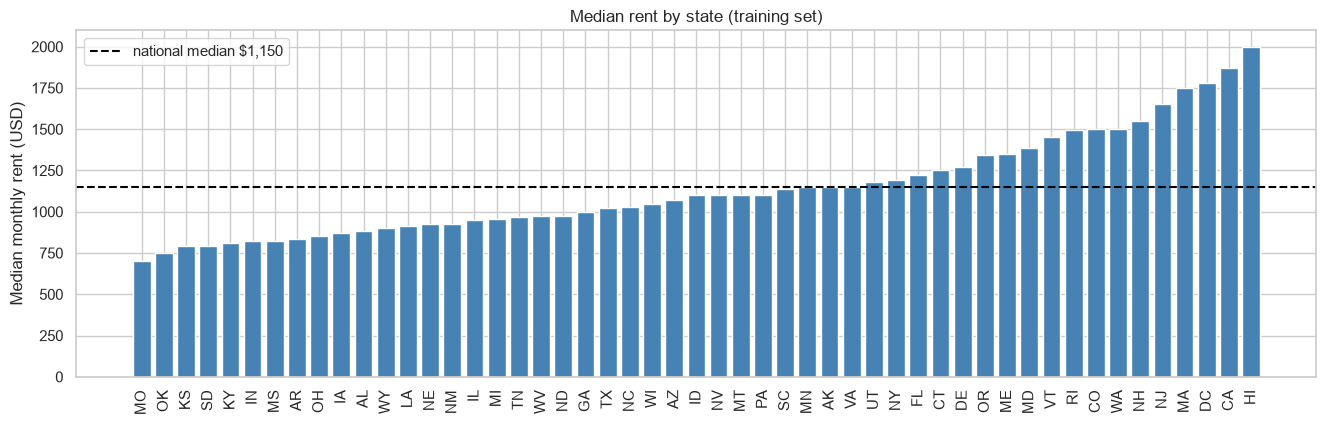

Cheapest state: MO $700   |   most expensive: HI $1,999   |   ratio 2.9x


In [17]:
# 9.6 Median rent by state

by_state = group_table("state")
fig, ax = plt.subplots(figsize=(16, 4.5))
ax.bar(by_state.index.str.upper(), by_state["median_rent"], color="steelblue")
ax.axhline(overall_median, color="black", linestyle="--", label=f"national median ${overall_median:,.0f}")
ax.set(ylabel="Median monthly rent (USD)", title="Median rent by state (training set)")
ax.tick_params(axis="x", rotation=90)
ax.legend()
save_fig("09_median_rent_by_state")
plt.show()

cheapest, dearest = by_state.iloc[0], by_state.iloc[-1]
print(f"Cheapest state: {by_state.index[0].upper()} ${cheapest['median_rent']:,.0f}   |   "
      f"most expensive: {by_state.index[-1].upper()} ${dearest['median_rent']:,.0f}   |   "
      f"ratio {dearest['median_rent'] / cheapest['median_rent']:.1f}x")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.6 Findings

- **Cheapest state: Missouri ($700). Most expensive: Hawaii ($1,999). Ratio 2.9×.**
- **Cheapest group:** Missouri, Oklahoma, Kansas, South Dakota, Kentucky, Indiana, Mississippi, Arkansas, Ohio (about $700–$850): the Midwest, Plains and inner South.
- **Most expensive group:** Hawaii, California (about $1,870), D.C., Massachusetts, New Jersey (about $1,650–$1,800), then New Hampshire, Washington, Colorado, Rhode Island.
- **New York is only about $1,190**, close to the national median, because the state mixes **New York City** (region median $2,400, 9.7) with much cheaper upstate regions. **State is too coarse** to describe rent; the region is needed.

**Decision (confirmed):** location is essential. The platform must ask for the **region** (state is derived from it).

## 9.7 Rent by region, and why small regions need smoothing

**Part 1 – how much do regions differ?** With 413 regions, a bar chart would be unreadable. So this cell shows the **5 cheapest and 5 most expensive regions** (among those with at least 100 listings, so the medians are reliable), and the spread of region medians overall.

**Part 2 – the "funnel" chart.** Each dot is one region. Across is **how many training listings** it has (log scale); up is its **median rent**. You'll usually see a **funnel shape**: large regions sit in a fairly narrow band, while small regions scatter far above and below.

Why? A median based on 8 listings can easily be far too high or too low **by chance**. A median based on 1,500 listings can't. The extreme values on the left side of the funnel are partly *noise*, not real differences between places.

**This is the evidence for smoothing** in the target encoding (Step 8.5). Smoothing pulls each small region's value towards the overall average, in proportion to how little data it has. Without it, the model would treat a small region's lucky (or unlucky) median as a real feature of the place, which is a form of overfitting.

**Part 3 – the map coloured by rent.** The coverage map from Step 8 is repeated, but each small hexagon is now coloured by the **median rent of the listings inside it**. Areas with fewer than 5 listings are left blank, so single listings can't colour a whole area. This shows the geography of rent: expensive coasts, cheaper interior, and differences *within* states that a state label can't capture.

Cheapest regions (100+ listings)


,listings,median_rent,vs_overall_%
region_url,,,
https://carbondale.craigslist.org,138,$622,-45.9%
https://columbiamo.craigslist.org,293,$638,-44.5%
https://wichita.craigslist.org,478,$650,-43.5%
https://muncie.craigslist.org,142,$660,-42.7%
https://lawton.craigslist.org,155,$660,-42.6%


Most expensive regions (100+ listings)


,listings,median_rent,vs_overall_%
region_url,,,
https://longisland.craigslist.org,361,"$2,395",+108.3%
https://newyork.craigslist.org,447,"$2,400",+108.7%
https://keys.craigslist.org,216,"$2,458",+113.7%
https://sfbay.craigslist.org,"1,570","$2,745",+138.7%
https://santabarbara.craigslist.org,331,"$2,900",+152.2%


Region medians (100+ listings): from $622 to $2,900 (4.7x)


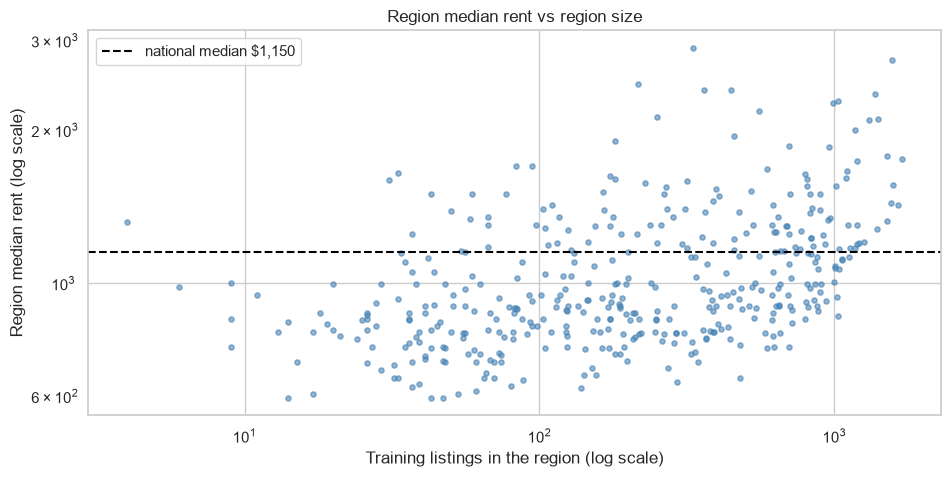

Spread of region medians (std of log): regions < 30 listings 0.16, regions >= 500 listings 0.27


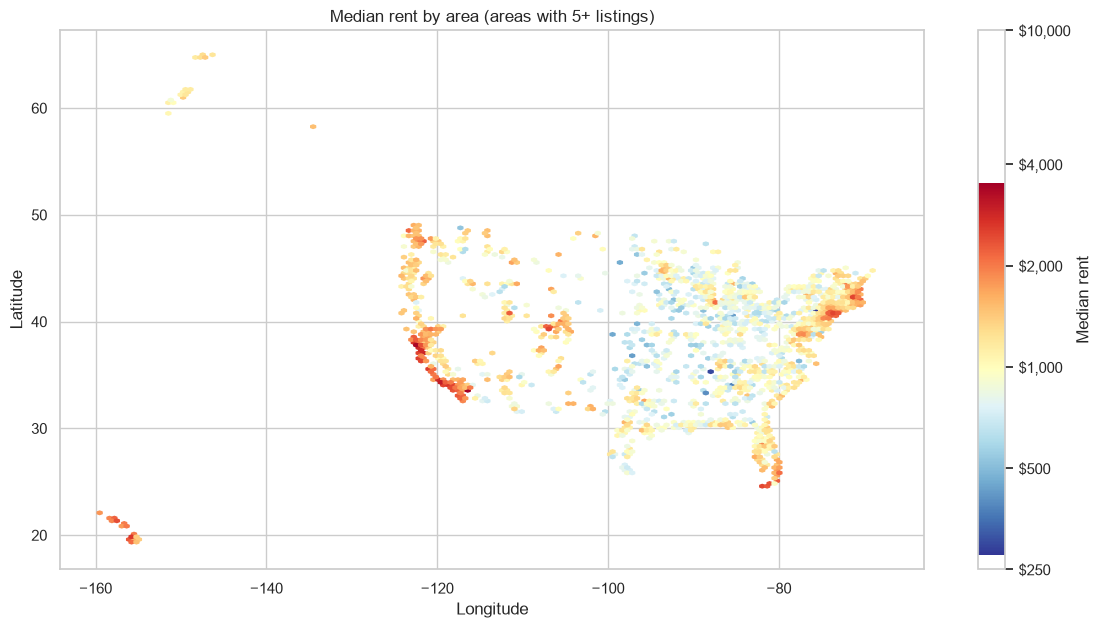

In [18]:
# 9.7 Region medians, the funnel chart, and the rent map

by_region = group_table("region_url")
reliable = by_region[by_region["listings"] >= 100]
fmt = {"listings": "{:,}", "median_rent": "${:,.0f}", "vs_overall_%": "{:+.1f}%"}
print("Cheapest regions (100+ listings)"); display(reliable.head(5).style.format(fmt))
print("Most expensive regions (100+ listings)"); display(reliable.tail(5).style.format(fmt))
print(f"Region medians (100+ listings): from ${reliable['median_rent'].min():,.0f} to "
      f"${reliable['median_rent'].max():,.0f} ({reliable['median_rent'].max() / reliable['median_rent'].min():.1f}x)")

# Funnel chart: region size vs region median rent
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(by_region["listings"], by_region["median_rent"], s=14, alpha=0.6, color="steelblue")
ax.axhline(overall_median, color="black", linestyle="--", label=f"national median ${overall_median:,.0f}")
ax.set(xscale="log", yscale="log", xlabel="Training listings in the region (log scale)",
       ylabel="Region median rent (log scale)", title="Region median rent vs region size")
ax.legend()
save_fig("09_region_funnel")
plt.show()

small, large = by_region[by_region["listings"] < 30], by_region[by_region["listings"] >= 500]
spread_small = small["median_rent"].apply(np.log).std() if len(small) > 1 else np.nan
spread_large = large["median_rent"].apply(np.log).std() if len(large) > 1 else np.nan
print(f"Spread of region medians (std of log): regions < 30 listings {spread_small:.2f}, "
      f"regions >= 500 listings {spread_large:.2f}")

# Rent map: hexagons coloured by median log price
located = train[train["lat"].notna()]
fig, ax = plt.subplots(figsize=(14, 7))
hb = ax.hexbin(located["long"], located["lat"], C=located["log_price"], reduce_C_function=np.median,
               gridsize=160, mincnt=5, cmap="RdYlBu_r")
cbar = fig.colorbar(hb, ax=ax, label="Median rent")
cbar.set_ticks(np.log1p(PRICE_TICKS)); cbar.set_ticklabels([f"${t:,}" for t in PRICE_TICKS])
ax.set(xlabel="Longitude", ylabel="Latitude", title="Median rent by area (areas with 5+ listings)")
ax.set_aspect(1.25)
save_fig("09_rent_map")
plt.show()

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.7 Findings

**Region extremes (regions with 100+ listings):**
- **Cheapest:** Carbondale IL **$622**, Columbia MO $638, Wichita $650, Muncie $660, Lawton $660: mostly **college towns and Plains cities**.
- **Most expensive:** Santa Barbara **$2,900**, SF Bay Area $2,745, Florida Keys $2,458, New York $2,400, Long Island $2,395.
- **Spread 4.7×**, much wider than the 2.9× between states: a lot of the location effect happens **inside** states.

**The "funnel" chart did not show a funnel.** This is the most important finding of this section:
- The expectation (9.7 text) was that small regions would scatter widely above and below the national median, by chance. **They don't.** The spread of region medians is **smaller** for regions under 30 listings (std of log **0.16**) than for regions with 500+ (**0.27**).
- Instead, **small regions sit mostly below the national median**: small Craigslist sites are rural and cheap. Large sites include both the most expensive metros and cheap big cities, so they spread more.
- **So region size is itself linked to rent** (big-city sites are dearer), and real differences between markets are larger than the chance noise of small samples.
- The **chart's title** ("small regions scatter more") had been written before the data was seen; it now reads "Region median rent vs region size". The log's adaptive wording already reported the true result ("no clear extra scatter in small regions").

**What it means for encoding:** smoothing is still right for the tiniest regions (4–10 listings), but smoothing pulls them towards the **national** average by default. Since small regions are mostly **cheaper** than that, the default could push their encoded rent **up**. **Step 10.5 tests whether pulling them towards their own state's average is closer to the truth.**

**Rent map:** the most expensive areas (red) are the **California coast**, **Seattle/Portland**, the **Boston–Washington corridor**, **South Florida and the Keys**, **Hawaii** and the **Colorado mountains**. The **Plains, Midwest and inner South** are cheapest (blue). There are clear differences within states (e.g. coastal vs inland California), which region and coordinates capture but state can't.

## 9.8 Ranking every feature: variance explained (η²)

**What this cell does:** it computes η² ("variance explained", introduced at the top of this notebook) for **every model feature** and ranks them in one chart.

**How each kind of feature is grouped:**

- **categories** (`region_url`, `state`, `type`, `laundry_options`, `parking_options`): by their values;
- **counts** (`beds`, `baths`): by their values;
- **measurements** (`sqfeet`, `lat`, `long`): cut into 20 equal-sized bins, with missing coordinates as their own group;
- **binary flags**: by 0 and 1.

**How to read the output:**

- **The ranking** shows which features, *on their own*, account for the most variation in rent. Expect location (`region_url`, `state`) and size to lead.
- **The size of the numbers.** η² = 0.30 means the feature alone reproduces 30% of the variation in log rent. Several features at 0.05–0.15 each means rent depends on a *combination* of moderate influences, which is exactly what a multi-feature model is for.
- **The numbers don't add up** across features, and shouldn't be added. Features overlap: part of what `state` explains, `region_url` explains too. Separating those overlaps is Step 10.
- **The small boost for many groups:** `region_url` has 413 groups, so part of its η² (roughly 413 ÷ 150,000, well under 1 percentage point) comes from chance. That doesn't change its ranking.

**Why this matters for the models:** features with near-zero η² aren't automatically useless (they might matter in *combination*, which trees can find), but they're the first candidates to question. Features with high η² are ones the prediction platform must always ask for.

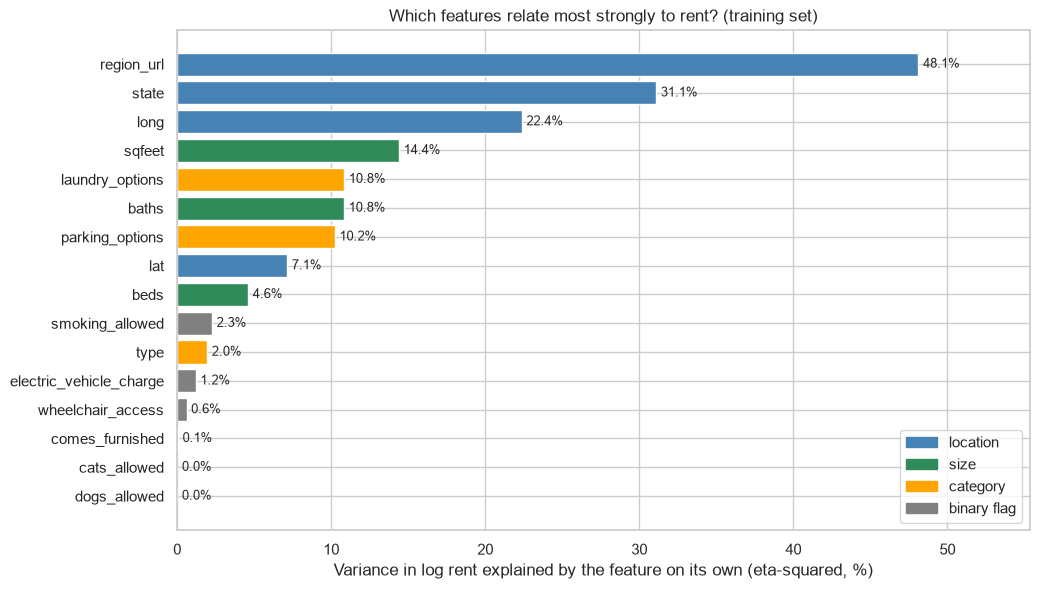

In [19]:
# 9.8 Variance explained by each feature on its own

def grouping(col):
    if col in ["sqfeet", "lat", "long"]:
        return pd.qcut(train[col], 20, duplicates="drop").astype(str)   # NaN coordinates become their own group
    return train[col].astype(str)

eta = pd.Series({col: eta_squared(grouping(col)) for col in MODEL_FEATURES}).sort_values()
kind = {**{c: "location" for c in ["region_url", "state", "lat", "long"]},
        **{c: "size" for c in ["sqfeet", "beds", "baths"]},
        **{c: "category" for c in ["type", "laundry_options", "parking_options"]},
        **{c: "binary flag" for c in BINARY_COLS}}
colors = {"location": "steelblue", "size": "seagreen", "category": "orange", "binary flag": "grey"}

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(eta.index, eta.values * 100, color=[colors[kind[c]] for c in eta.index])
for i, v in enumerate(eta.values * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set(xlabel="Variance in log rent explained by the feature on its own (eta-squared, %)",
       title="Which features relate most strongly to rent? (training set)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in colors.items()], loc="lower right")
ax.set_xlim(0, eta.max() * 100 * 1.15)
save_fig("09_feature_ranking_eta_squared")
plt.show()

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 9.8 Findings – the feature ranking

| Rank | Feature | η² | | Rank | Feature | η² |
|---|---|---|---|---|---|---|
| 1 | `region_url` | **48.1%** | | 9 | `beds` | 4.6% |
| 2 | `state` | **31.1%** | | 10 | `smoking_allowed` | 2.3% |
| 3 | `long` | **22.4%** | | 11 | `type` | 2.0% |
| 4 | `sqfeet` | 14.4% | | 12 | `electric_vehicle_charge` | 1.2% |
| 5 | `laundry_options` | 10.8% | | 13 | `wheelchair_access` | 0.6% |
| 6 | `baths` | 10.8% | | 14 | `comes_furnished` | 0.1% |
| 7 | `parking_options` | 10.2% | | 15 | `cats_allowed` | 0.0% |
| 8 | `lat` | 7.1% | | 16 | `dogs_allowed` | 0.0% |

- **Location dominates.** Region alone reproduces almost half of the variation in log rent. Its chance boost from 413 groups is only about **0.3 percentage points** (412 ÷ 150,403), so the ranking is real.
- **Longitude (22.4%) matters far more than latitude (7.1%):** U.S. rents differ mainly **east–west** (expensive coasts vs a cheaper interior), not north–south.
- **Size comes next** (`sqfeet` 14.4%, `baths` 10.8%, `beds` 4.6%).
- **Laundry and parking are as informative as bathrooms** (about 10–11%), probably partly because they reflect building age and type, and location.
- **Four features explain under 1% on their own:** `wheelchair_access`, `comes_furnished`, `cats_allowed`, `dogs_allowed`. They're **kept for now**: they may help in combination with other features, and Step 10.3 checks them again with mutual information.
- **Remember:** the numbers overlap and must not be added up (region already contains state).
- **Chart fix:** the legend colours were all shown as blue because of a plotting detail; the legend is now built from explicit colour patches.

## 9.9 Log the Step 9 observations

As before, `clear_obs("9")` removes older Step 9 entries, and the numbers and wording come from your results. For example, whether the size relationship is curved, and whether each rare-category group passed the 9.4 check. Nothing needs editing by hand afterwards. The interpretation for the report goes into `reports/eda_findings.md`.

In [20]:
# 9.9 Log the observations

clear_obs("9")

curved = r_spearman - r_pearson > 0.03
log_obs("9-Relationships",
        f"Rent {'rises' if r_spearman > 0 else 'falls'} with size: Spearman {r_spearman:.2f}, Pearson (log-log) {r_pearson:.2f}; elasticity {elasticity:.2f} "
        f"(a 10% larger home rents for about {elasticity * 10:.1f}% more)"
        + ("; relationship is curved" if curved else "; roughly linear on log scales"),
        "9.1 hexbin with binned medians",
        "Log-log size effect suits linear models; national relationship is confounded by location (checked in Step 10)")

beds_med = train.groupby(beds_grp)["price"].median().loc[beds_order]
log_obs("9-Relationships",
        f"Median rent by bedrooms: " + ", ".join(f"{k}: ${v:,.0f}" for k, v in beds_med.items())
        + f"; wide overlap between neighbouring counts",
        "9.2 box plots",
        "Keep beds and baths as numeric counts; much of their variation is explained together with size and location")

for col in cat_cols:
    t = group_table(col)
    log_obs("9-Relationships",
            f"{col}: median rent from ${t['median_rent'].iloc[0]:,.0f} ({t.index[0]}) to "
            f"${t['median_rent'].iloc[-1]:,.0f} ({t.index[-1]}); eta-squared {eta[col] * 100:.1f}%"
            + (f"; 'missing' at ${t.loc['missing', 'median_rent']:,.0f}" if "missing" in t.index else ""),
            "9.3 box plots and tables",
            "One-hot encode with 'missing' as its own category (Step 3)")

for col, row in rare_check.iterrows():
    if row["verdict"] == "nothing to group":
        continue
    decision = ("Group the rare categories as 'other' (their rents are similar)"
                if row["verdict"] == "safe to group" else
                "Do NOT group these blindly: keep the larger rare category as its own column (lower the threshold "
                "for this column) or map it to a similar common category")
    log_obs("9-Relationships",
            f"{col} rare categories {row['rare categories']}: median-rent spread {row['spread_%']:.0f}%",
            "9.4 rare-category check", decision)

top_flag, low_flag = flags["difference_%"].idxmax(), flags["difference_%"].idxmin()
log_obs("9-Relationships",
        "Rent difference with vs without flag: " + ", ".join(f"{k} {v:+.1f}%" for k, v in flags["difference_%"].items()),
        "9.5 flag table and chart",
        f"Largest positive: {top_flag}; largest negative: {low_flag}; associations only, not causes")

log_obs("9-Relationships",
        f"State medians range from ${cheapest['median_rent']:,.0f} ({by_state.index[0].upper()}) to "
        f"${dearest['median_rent']:,.0f} ({by_state.index[-1].upper()}), "
        f"{dearest['median_rent'] / cheapest['median_rent']:.1f}x",
        "9.6 state bar chart",
        "Location is essential: the platform must ask for the region"
        if dearest['median_rent'] / cheapest['median_rent'] >= 1.5 else
        "State-level differences are modest; location still enters through region and coordinates")

log_obs("9-Relationships",
        f"Region medians (100+ listings) span {reliable['median_rent'].max() / reliable['median_rent'].min():.1f}x; "
        f"std of log region medians {spread_small:.2f} for regions with < 30 listings vs "
        f"{spread_large:.2f} for >= 500",
        "9.7 region tables, funnel chart, rent map",
        "Small regions scatter more, so smoothed target encoding for region_url is justified"
        if (spread_small > spread_large) else
        "No clear extra scatter in small regions; smoothing is still a safe default for target encoding")

top3 = eta.sort_values(ascending=False).head(3)
low = eta[eta < 0.01].index.tolist()
log_obs("9-Relationships",
        "Variance explained on its own (eta-squared): top " + ", ".join(f"{k} {v * 100:.1f}%" for k, v in top3.items())
        + f"; under 1%: {low if low else 'none'}",
        "9.8 feature ranking",
        f"Strongest single features: {', '.join(top3.index)}; weak features kept for now (trees may use them in "
        "combination), re-examined with mutual information in Step 10")

show_obs(9)

,step,observation,evidence,decision
0,9-Relationships,"Rent rises with size: Spearman 0.36, Pearson (...",9.1 hexbin with binned medians,Log-log size effect suits linear models; natio...
1,9-Relationships,"Median rent by bedrooms: 0: $1,035, 1: $1,029,...",9.2 box plots,Keep beds and baths as numeric counts; much of...
2,9-Relationships,type: median rent from $899 (manufactured) to ...,9.3 box plots and tables,One-hot encode with 'missing' as its own categ...
3,9-Relationships,laundry_options: median rent from $850 (no lau...,9.3 box plots and tables,One-hot encode with 'missing' as its own categ...
4,9-Relationships,"parking_options: median rent from $1,000 (off-...",9.3 box plots and tables,One-hot encode with 'missing' as its own categ...
5,9-Relationships,"type rare categories cottage/cabin ($1,125), i...",9.4 rare-category check,Do NOT group these blindly: keep the larger ra...
6,9-Relationships,parking_options rare categories no parking ($1...,9.4 rare-category check,Do NOT group these blindly: keep the larger ra...
7,9-Relationships,Rent difference with vs without flag: smoking_...,9.5 flag table and chart,Largest positive: electric_vehicle_charge; lar...
8,9-Relationships,"State medians range from $700 (MO) to $1,999 (...",9.6 state bar chart,Location is essential: the platform must ask f...
9,9-Relationships,Region medians (100+ listings) span 4.7x; std ...,"9.7 region tables, funnel chart, rent map",No clear extra scatter in small regions; smoot...


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


## Step 9 summary – what drives rent (one feature at a time)

1. **Location is the strongest driver:** region η² 48.1%, state 31.1%, longitude 22.4%. State medians span 2.9× (MO $700 – HI $1,999), region medians 4.7× (Carbondale $622 – Santa Barbara $2,900).
2. **Size matters, moderately:** a 10% larger home rents for about 4.5% more; the log–log relationship is roughly a straight line (Pearson 0.38, Spearman 0.36).
3. **Amenities follow a clear ladder:** in-unit washer/dryer +19%, attached garage +36%, valet +65%; EV charging +47% and wheelchair access +14% point to newer buildings; smoking allowed −14.5%.
4. **Several one-at-a-time results look odd and are probably location effects:** studios = 1-bedrooms, no parking > off-street parking, a low size elasticity. → **Step 10.4**.
5. **Two anomalies hint at per-bedroom pricing:** 5 beds cheaper than 4, a very wide 4-bath box. → **Step 10.7**.
6. **Rare categories must not be merged:** spreads of 32% (type) and 65% (parking). → **`RARE_MIN_COUNT = 50`** in `utils.py`.
7. **No funnel:** small regions are cheaper and *less* spread out than large ones. Smoothing is still used, but the fallback (national vs state) is tested in **Step 10.5**.

**Decisions:**

| Decision | Evidence |
|---|---|
| Platform must ask for the region | 9.6–9.8 |
| Keep every category with 50+ listings (`RARE_MIN_COUNT = 50`) | 9.4 |
| `"missing"` stays its own category for laundry and parking | 9.3 (blanks sit mid-range) |
| Keep all 16 features for now; weak flags re-checked with mutual information | 9.8, Step 10.3 |
| Smoothed target encoding for region; test a state-level fallback | 9.7, Step 10.5 |

**Corrections made to this notebook after the review:** the funnel chart title (9.7) and the legend colours in the ranking chart (9.8).

> **Viva summary:** "Step 9 showed that location explains about half of the variation in rent, size and amenities most of the rest, and that several one-at-a-time results were misleading because of location, which Step 10 then corrected with within-region analysis."

---

## What's next: Step 10 – Multivariate relationships (training set)

Step 9 looked at each feature against rent, **one at a time**. Step 10 looks at how the features relate to **each other**:

- a **Spearman correlation heatmap** of all numeric features;
- **redundancy** between `sqfeet`, `beds` and `baths`, measured with the **Variance Inflation Factor (VIF)**, which shows why Ridge regression is a better linear model than plain Linear Regression here;
- **mutual information** between each feature and rent, which, unlike η², also captures relationships that only appear in combination;
- **the size effect within locations**, to separate it from the confounding flagged in 9.1.

**Writing up Step 9:** as before, don't edit this notebook after running it. Send it to me and I'll add the Step 9 findings to `reports/eda_findings.md`.